In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# **Preparing The Dataset**

In [11]:
columns = ["Age","Sex","ChestPainType", "RestingBP","Cholesterol","FastingBS","RestingECG","MaxHR","ExerciseAngina","Oldpeak","ST_Slope","HeartDisease"]
df = pd.read_csv("heart.csv", names=columns, header=0)
print("Dataframe shape : ",df.shape)
df.head()

Dataframe shape :  (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# **Cleaning The Dataset**

In [12]:
df["Cholesterol"] = df["Cholesterol"].replace(0, df["Cholesterol"].median())
df["RestingBP"] = df["RestingBP"].replace(0, df["RestingBP"].median())

In [13]:
# Removing rows with missing values
df = df.dropna(subset=["Age","Sex","ChestPainType", "RestingBP","Cholesterol","FastingBS","RestingECG","MaxHR","ExerciseAngina","Oldpeak","ST_Slope","HeartDisease"])

# Encoding Categorical columns
cat_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=cat_columns, drop_first=False)

# Data frame shape after encoding
print("Dataframe shape : ",df_encoded.shape)

# Columns after encoding
print("Columns : ",df_encoded.columns)

Dataframe shape :  (918, 21)
Columns :  Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


# **Data Splitting and Scaling**
Multinomial Naive Bayes strictly requires non-negative features. We will use MinMaxScaler to scale the features to a [0, 1] range before applying SMOTE.

In [14]:
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

# Splitting the dataset prior to SMOTE to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling the data to ensure no negative values exist (e.g. from the 'Oldpeak' column)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Applying SMOTE (Since The Dataset is Imbalanced)**

In [15]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE : ", Counter(y_train))
print("After SMOTE : ",Counter(y_train_resampled))

Before SMOTE :  Counter({1: 401, 0: 333})
After SMOTE :  Counter({0: 401, 1: 401})


# **Model Creation and Training (Multinomial Naive Bayes)**

In [16]:
# Initializing the Multinomial Naive Bayes model
mnb_model = MultinomialNB()

# Train the model using the SMOTE resampled and scaled training data
mnb_model.fit(X_train_resampled, y_train_resampled)

# Make predictions using the scaled test set
y_pred = mnb_model.predict(X_test_scaled)

In [17]:
# Accuracy of Multinomial Naive Bayes Model
print("Accuracy : {:.4f}".format(accuracy_score(y_test, y_pred)))

# Classification Report
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8261

Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81        77
           1       0.90      0.79      0.84       107

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.82       184
weighted avg       0.84      0.83      0.83       184



# **Confusion Matrix**

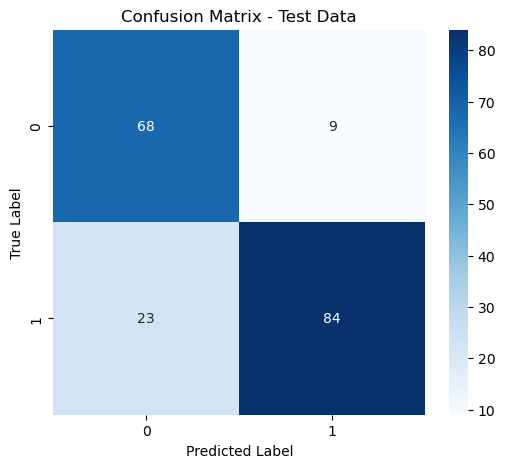

In [18]:
# Plot confusion matrix for test set
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Data')
plt.show()

# **Training and Validation Accuracy (Learning Curve)**

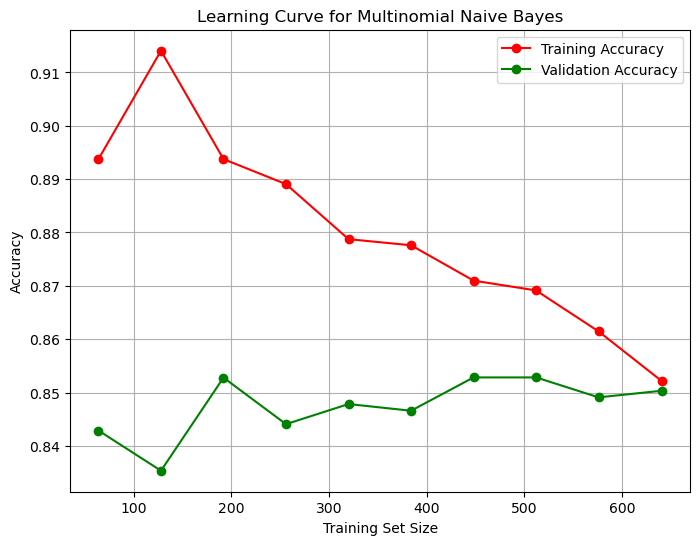

In [19]:
# Plot learning curve
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=MultinomialNB(),
    X=X_train_resampled,
    y=y_train_resampled,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label="Training Accuracy")
plt.plot(train_sizes, validation_scores_mean, 'o-', color='g', label="Validation Accuracy")
plt.title("Learning Curve for Multinomial Naive Bayes")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()
